##1. Build a linear layer manually

In [1]:
import torch
import torch.nn as nn

# Manually implement what nn.Linear does internally
class ManualLinearLayer:
    def __init__(self, in_features, out_features):
        # Random initialization — this is what PyTorch does internally
        self.weights = torch.randn(out_features, in_features,
                                   requires_grad=True)
        self.bias = torch.randn(out_features,
                                requires_grad=True)

    def forward(self, x):
        # output = weights × input + bias
        return x @ self.weights.T + self.bias

# Test it
layer = ManualLinearLayer(in_features=13, out_features=32)
# Simulate 1 pixel with 13 spectral band values
pixel = torch.randn(1, 13)
output = layer.forward(pixel)
print(f"Input shape: {pixel.shape}")
print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 13])
Output shape: torch.Size([1, 32])
Output: tensor([[ 4.0989e+00,  1.0429e+00,  5.5330e+00, -7.3290e+00, -1.7170e+00,
         -2.7846e+00,  1.0973e+00,  3.0037e+00, -1.8537e+00, -8.1475e-01,
          6.7465e+00, -1.0527e+01, -4.3268e+00,  1.5580e+00,  6.3625e+00,
          4.8518e+00,  6.4416e+00,  8.6543e+00,  7.6566e-01,  1.4566e+00,
         -1.7912e+00, -3.7660e+00,  7.6541e+00,  8.0284e+00,  1.3576e+00,
         -6.9491e+00, -6.1950e-03,  1.6348e+00, -3.1222e+00, -6.7946e+00,
         -4.1123e+00, -9.2844e-01]], grad_fn=<AddBackward0>)


## 2. Use of Pytorch's .nn

In [4]:
import torch.nn.functional as F

class SpectralClassifier(nn.Module):
    """
    Simple network to classify a single pixel's spectral signature.
    Input: 13 band values (Sentinel-2 pixel)
    Output: probability across 10 land-cover classes
    """
    def __init__(self):
        super(SpectralClassifier, self).__init__()

        # Define layers
        self.layer1 = nn.Linear(13, 64)   # 13 bands → 64 neurons
        self.layer2 = nn.Linear(64, 32)   # 64 → 32
        self.layer3 = nn.Linear(32, 10)   # 32 → 10 classes

    def forward(self, x):
        # Forward pass — data flows through layers
        x = F.relu(self.layer1(x))   # Linear + ReLU
        x = F.relu(self.layer2(x))   # Linear + ReLU
        x = self.layer3(x)           # Linear only — softmax applied in loss
        return x

# Create model
model = SpectralClassifier()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal learnable parameters: {total_params}")




SpectralClassifier(
  (layer1): Linear(in_features=13, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=10, bias=True)
)

Total learnable parameters: 3306


## 3. Run a full forward and backward pass

In [8]:
# Simulate a batch of 32 Sentinel-2 pixels, each with 13 band values
batch_size = 32
pixel_batch = torch.randn(batch_size, 13)

# Simulate ground truth labels (0-9 for 10 land cover classes)
# e.g. 0=water, 1=forest, 2=urban, 3=cropland...
labels = torch.randint(0, 10, (batch_size,))

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- FORWARD PASS ---
predictions = model(pixel_batch)
print(f"Predictions shape: {predictions.shape}")  # [32, 10]

# --- COMPUTE LOSS ---
loss = criterion(predictions, labels)
print(f"Loss before training: {loss.item():.4f}")

# --- BACKWARD PASS ---
optimizer.zero_grad()   # Clear old gradients — critical, never forget this
loss.backward()         # Compute gradients
optimizer.step()        # Update weights

print(f"Gradients on layer1 weights (first 3): "
      f"{model.layer1.weight.grad[0][:3]}")
print("One training step complete.")

Predictions shape: torch.Size([32, 10])
Loss before training: 2.3105
Gradients on layer1 weights (first 3): tensor([ 0.0008, -0.0001,  0.0041])
One training step complete.


## 4. Train for 100 steps and watch for loss


Step   0 | Loss: 2.3100
Step  20 | Loss: 2.3326
Step  40 | Loss: 2.2957
Step  60 | Loss: 2.2970
Step  80 | Loss: 2.3167


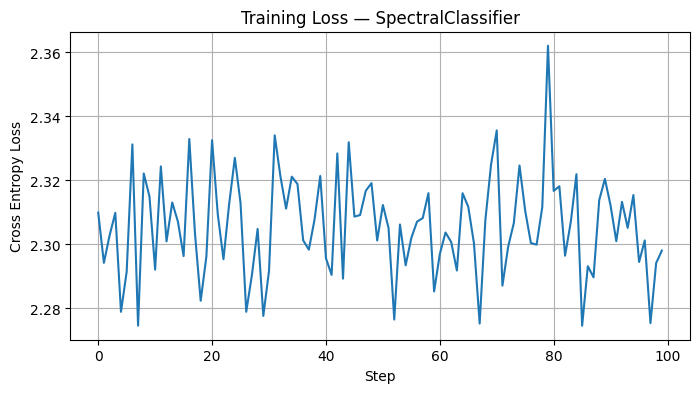


Loss went from 2.3100 → 2.2981


In [13]:
losses = []

for step in range(100):
    # Fresh random batch each step
    pixel_batch = torch.randn(32, 13)
    labels = torch.randint(0, 10, (32,))

    # Forward
    predictions = model(pixel_batch)
    loss = criterion(predictions, labels)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if step % 20 == 0:
        print(f"Step {step:3d} | Loss: {loss.item():.4f}")

# Plot loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title("Training Loss — SpectralClassifier")
plt.xlabel("Step")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

print(f"\nLoss went from {losses[0]:.4f} → {losses[-1]:.4f}")

## What I learned today

- A neural network layer is: output = activation(W×x + b)
- Without activation functions, deep networks collapse to linear
- SpectralClassifier has [X] parameters — computed manually
- Loss dropped from [X] to [X] in 100 steps on random data
- optimizer.zero_grad() is needed because PyTorch accumulates
  gradients by default — if forgotten, gradients from previous
  steps corrupt the current update

## Space connection
This exact architecture (13 inputs → hidden layers → class output)
is used for hyperspectral pixel classification in satellite imagery.
The 13 inputs map directly to Sentinel-2's 13 spectral bands.
A full image is classified pixel-by-pixel or with spatial context
added via convolution.